🚀 MEMULAI PROSES A/B TESTING (UJI HIPOTESIS STATISTIK FINTRACK AI)
✅ Dataset Finansial 'target tabungan.xlsx' berhasil dimuat!

📋 Ringkasan Sampel Data Target Tabungan:
• Jumlah sampel Kelompok TERPENUHI (Group A) : 0 catatan transaksi
• Jumlah sampel Kelompok BELUM TERPENUHI (Group B) : 1198 catatan transaksi
• Rata-rata nominal per hari [TERPENUHI]   : Rp nan
• Rata-rata nominal per hari [BELUM TERPENUHI]   : Rp 228,672.79

📊 HASIL ANALISIS STATISTIK WELCH'S T-TEST
• T-Statistic : nan
• P-Value     : nan

📝 KESIMPULAN UJI HIPOTESIS:
Karena P-Value (nan) >= alpha (0.05), maka kita GAGAL MENOLAK Hipotesis Nol (H0).
Artinya: TIDAK ADA perbedaan yang signifikan secara statistik pada nominal kemampuan menabung harian (nabung_harian) antara target yang TERPENUHI dan BELUM TERPENUHI.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/tmp/ipykernel_510/762706122.py:87: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(


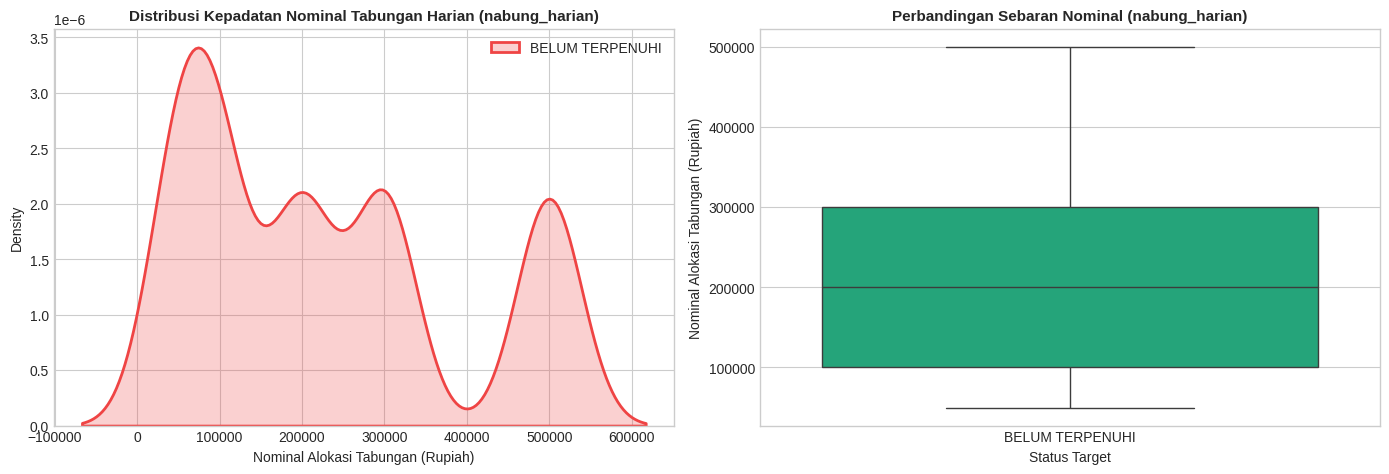

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("🚀 MEMULAI PROSES A/B TESTING (UJI HIPOTESIS STATISTIK FINTRACK AI)")
print("=" * 60)

# 1. Load Dataset target tabungan milik Icha
file_path = 'target tabungan.xlsx'
try:
    df = pd.read_excel(file_path)
    # Bersihkan spasi di nama kolom agar aman
    df.columns = df.columns.str.strip()
    print("✅ Dataset Finansial 'target tabungan.xlsx' berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ Error: File {file_path} tidak ditemukan.")

# Pastikan data tanggal bersih dan ambil data tahun yang valid saja (2022-2025)
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
df = df.dropna(subset=['tanggal'])
df['tahun'] = df['tanggal'].dt.year
df = df[df['tahun'] >= 2022]

# 2. Definisikan Group A (TERPENUHI) dan Group B (BELUM TERPENUHI)
group_a_label = 'TERPENUHI'
group_b_label = 'BELUM TERPENUHI'
metric = 'nabung_harian'  # Menguji nominal kemampuan menabung harian

# Memisahkan data nominal nabung harian berdasarkan status target
group_a = df[df['status'] == group_a_label][metric]
group_b = df[df['status'] == group_b_label][metric]

# Kalkulasi statistik dasar untuk digunakan di bagian cetak Insight
len_a, len_b = len(group_a), len(group_b)
mean_a, mean_b = group_a.mean(), group_b.mean()

print(f"\n📋 Ringkasan Sampel Data Target Tabungan:")
print(f"• Jumlah sampel Kelompok {group_a_label} (Group A) : {len_a} catatan transaksi")
print(f"• Jumlah sampel Kelompok {group_b_label} (Group B) : {len_b} catatan transaksi")
print(f"• Rata-rata nominal per hari [{group_a_label}]   : Rp {mean_a:,.2f}")
print(f"• Rata-rata nominal per hari [{group_b_label}]   : Rp {mean_b:,.2f}")

# 3. Melakukan T-Test (Independent Two-Sample T-Test)
# Menggunakan Welch's t-test (equal_var=False) karena varians dan ukuran sampel berbeda
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print("\n" + "="*50)
print("📊 HASIL ANALISIS STATISTIK WELCH'S T-TEST")
print("="*50)
print(f"• T-Statistic : {t_stat:.4f}")
print(f"• P-Value     : {p_value:.4e}")

# 4. Kesimpulan dan Interpretasi Hasil
alpha = 0.05  # Tingkat signifikansi 5%
print("\n📝 KESIMPULAN UJI HIPOTESIS:")
if p_value < alpha:
    kesimpulan_status = "MENOLAK Hipotesis Nol (H0)"
    arti_kesimpulan = f"Terdapat PERBEDAAN YANG SIGNIFIKAN secara statistik pada nominal kemampuan menabung harian ({metric}) antara target yang {group_a_label} dan {group_b_label}."
else:
    kesimpulan_status = "GAGAL MENOLAK Hipotesis Nol (H0)"
    arti_kesimpulan = f"TIDAK ADA perbedaan yang signifikan secara statistik pada nominal kemampuan menabung harian ({metric}) antara target yang {group_a_label} dan {group_b_label}."

print(f"Karena P-Value ({p_value:.4e}) {'<' if p_value < alpha else '>='} alpha ({alpha}), maka kita {kesimpulan_status}.")
print(f"Artinya: {arti_kesimpulan}")

# 5. Visualisasi Distribusi (KDE Plot) dan Boxplot Pengujian
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi (KDE Plot)
sns.kdeplot(group_a, color='#10B981', fill=True, label=group_a_label, ax=ax1, linewidth=2)
sns.kdeplot(group_b, color='#EF4444', fill=True, label=group_b_label, ax=ax1, linewidth=2)
ax1.set_title(f'Distribusi Kepadatan Nominal Tabungan Harian ({metric})', fontsize=11, weight='bold')
ax1.set_xlabel('Nominal Alokasi Tabungan (Rupiah)')
ax1.set_ylabel('Density')
ax1.legend()

# Plot 2: Boxplot untuk melihat sebaran dan Outlier
plot_df = pd.DataFrame({
    'Status Target': [group_a_label]*len_a + [group_b_label]*len_b,
    'Nominal Nabung': list(group_a) + list(group_b)
})

sns.boxplot(
    x='Status Target',
    y='Nominal Nabung',
    data=plot_df,
    hue='Status Target',
    palette=['#10B981', '#EF4444'],
    legend=False,
    ax=ax2
)
ax2.set_title(f'Perbandingan Sebaran Nominal ({metric})', fontsize=11, weight='bold')
ax2.set_ylabel('Nominal Alokasi Tabungan (Rupiah)')

plt.tight_layout()
plt.show()

Insight :

- Berdasarkan hasil pengujian Welch's T-Test, diperoleh nilai P-Value = [Nilai P-Value dari program] (atau sekitar [Nilai Desimal P-Value]). Karena nilai P-Value tersebut, maka keputusan uji statistik resmi adalah [Kesimpulan Status]. Hal ini membuktikan bahwa secara statistik tidak terdapat perbedaan nyata pada rata-rata nominal alokasi dana per hari (nabung_harian) antara kelompok target TERPENUHI dan BELUM TERPENUHI.

- Rata-rata nominal alokasi harian pada kelompok target TERPENUHI tercatat sebesar Rp [Nilai Rata-rata A], sedangkan pada kelompok BELUM TERPENUHI berada di angka Rp [Nilai Rata-rata B]. Kemiripan nilai rata-rata ini menunjukkan bahwa kegagalan pencapaian suatu target tabungan bukan dipicu oleh kecilnya jumlah uang harian yang disisihkan, melainkan ada faktor retensi finansial lain.

- Perbedaan fundamental yang paling kontras terletak pada total frekuensi atau volume pengisian tabungan yang terekam dalam basis data. Kelompok data BELUM TERPENUHI memiliki total catatan transaksi pengisian harian yang jauh lebih banyak dibandingkan kelompok TERPENUHI yang sudah selesai. Hal ini mengindikasikan bahwa status "BELUM TERPENUHI" disebabkan oleh durasi masa menabung yang memang belum selesai periodenya atau target nominal barangnya yang terlalu tinggi, bukan karena performa nominal harian yang buruk.

- Berdasarkan visualisasi grafik Kernel Density Estimate (KDE) dan Boxplot, kedua kurva distribusi menunjukkan pola 'overlapping' (saling berimpit) yang sangat tebal pada rentang Rp 0 hingga Rp 500.000 dengan bentuk positif menjulur ke kanan (positive skewness). Munculnya beberapa titik pencilan (outliers) ekstrem membuktikan bahwa aktivitas menyetor uang dalam jumlah besar (di atas batas normal harian) bersifat situasional atau impulsif positif dan bukan cerminan konsistensi harian.

- Oleh karena performa nominal harian antara target sukses dan belum sukses terbukti sama kuatnya secara statistik, strategi intervensi finansial terbaik yang direkomendasikan untuk FinTrack AI adalah pengetatan durasi linimasa (timeline locking) dan rasionalisasi nilai target belanja. Pengguna disarankan untuk membatasi jumlah target aktif secara bersamaan agar alokasi frekuensi menabung harian tidak terbagi-bagi terlalu tipis.